# Plant Disease Prediction

## Importing Dataset

Dataset Link: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset

## Importing libraries

In [17]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Data Preprocessing

### Training Image preprocessing

In [18]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'plantvillage',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 20638 files belonging to 15 classes.


### Validation Image Preprocessing

In [19]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'plantvillage',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 20638 files belonging to 15 classes.


#### To avoid Overshooting Loss function
1. Choose small learning rate default 0.001 here we have taken 0.0001
2. There may be chance of underfitting so increase number of neuron
3. Add more Convolutional Layer to extract more feature from images there may be possibilty that model unable to capture relevant feature or model is confusing due to lack of feature so feed with more feature

## Building Model

In [20]:
model = tf.keras.models.Sequential()

### Building Convolution Layer

In [21]:
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [22]:
model.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [23]:
model.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [24]:
model.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [25]:
model.add(tf.keras.layers.Dropout(0.25)) #To avoid overfitting

In [26]:
model.add(tf.keras.layers.Flatten())

In [27]:
model.add(tf.keras.layers.Dense(units=1024,activation='relu'))

In [28]:
model.add(tf.keras.layers.Dropout(0.4)) #To avoid overfitting

In [29]:
#Output Layer
model.add(tf.keras.layers.Dense(units=15,activation='softmax'))

### Compiling and Training Phase

In [30]:
model.compile(optimizer=tf.keras.optimizers.legacy.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [31]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 128, 128, 32)      896       
                                                                 
 conv2d_9 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 63, 63, 64)        18496     
                                                                 
 conv2d_11 (Conv2D)          (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                  

In [32]:
training_history = model.fit(x=training_set,validation_data=validation_set,epochs=5)

Epoch 1/5
645/645 [==============================] - 2115s 3s/step - loss: 1.1774 - accuracy: 0.6265 - val_loss: 0.5437 - val_accuracy: 0.8231
Epoch 2/5
645/645 [==============================] - 1964s 3s/step - loss: 0.4866 - accuracy: 0.8391 - val_loss: 0.2430 - val_accuracy: 0.9237
Epoch 3/5
645/645 [==============================] - 1918s 3s/step - loss: 0.3041 - accuracy: 0.8996 - val_loss: 0.1569 - val_accuracy: 0.9495
Epoch 4/5
645/645 [==============================] - 1363s 2s/step - loss: 0.2171 - accuracy: 0.9265 - val_loss: 0.1111 - val_accuracy: 0.9668
Epoch 5/5
645/645 [==============================] - 1380s 2s/step - loss: 0.1551 - accuracy: 0.9461 - val_loss: 0.0691 - val_accuracy: 0.9796


## Evaluating Model

In [33]:
#Training set Accuracy
train_loss, train_acc = model.evaluate(training_set)
print('Training accuracy:', train_acc)

645/645 [==============================] - 264s 409ms/step - loss: 0.0691 - accuracy: 0.9796
Training accuracy: 0.979600727558136


In [34]:
#Validation set Accuracy
val_loss, val_acc = model.evaluate(validation_set)
print('Validation accuracy:', val_acc)

645/645 [==============================] - 260s 402ms/step - loss: 0.0691 - accuracy: 0.9796
Validation accuracy: 0.979600727558136


### Saving Model

In [35]:
model.save('trained_plant_disease_model_plantvillage.keras')

In [36]:
training_history.history #Return Dictionary of history

{'loss': [1.1773754358291626,
  0.4865594804286957,
  0.3040575385093689,
  0.21714824438095093,
  0.1550680696964264],
 'accuracy': [0.6264657378196716,
  0.8390832543373108,
  0.8995541930198669,
  0.9265432953834534,
  0.9460703730583191],
 'val_loss': [0.543685793876648,
  0.24296781420707703,
  0.15693452954292297,
  0.11113100498914719,
  0.06913448125123978],
 'val_accuracy': [0.8230932950973511,
  0.9237329363822937,
  0.9495106339454651,
  0.9668087959289551,
  0.979600727558136]}

In [37]:
#Recording History in json
import json
with open('training_hist.json','a') as f:
  json.dump(training_history.history,f)

In [38]:
print(training_history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


## Accuracy Visualization

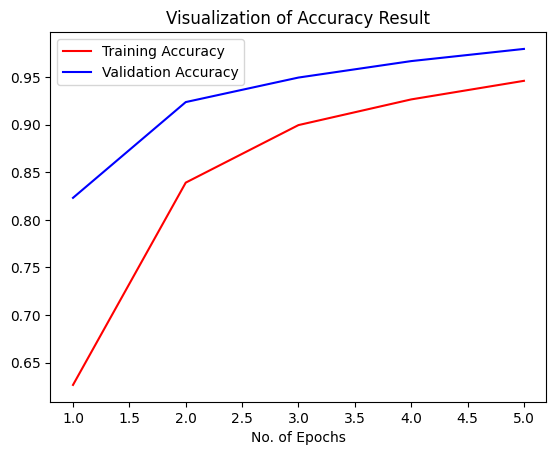

In [40]:
epochs = [i for i in range(1,6)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

## Some other metrics for model evaluation

In [41]:
class_name = validation_set.class_names
class_name

['Pepper__bell___Bacterial_spot',
 'Pepper__bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

In [43]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'plantvillage',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 20638 files belonging to 15 classes.


In [44]:
y_pred = model.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)

20638/20638 [==============================] - 663s 32ms/step


In [45]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = tf.argmax(true_categories, axis=1)

In [46]:
Y_true

<tf.Tensor: shape=(20638,), dtype=int64, numpy=array([ 0,  0,  0, ..., 14, 14, 14], dtype=int64)>

In [47]:
predicted_categories

<tf.Tensor: shape=(20638,), dtype=int64, numpy=array([ 0,  0,  0, ..., 14, 14, 14], dtype=int64)>

In [48]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)

In [49]:
# Precision Recall Fscore
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.98      1.00      0.99       997
                     Pepper__bell___healthy       1.00      0.99      0.99      1478
                      Potato___Early_blight       0.96      1.00      0.98      1000
                       Potato___Late_blight       0.94      0.99      0.96      1000
                           Potato___healthy       0.97      0.95      0.96       152
                      Tomato_Bacterial_spot       0.98      0.99      0.98      2127
                        Tomato_Early_blight       0.96      0.94      0.95      1000
                         Tomato_Late_blight       0.99      0.96      0.97      1909
                           Tomato_Leaf_Mold       0.96      0.99      0.97       952
                  Tomato_Septoria_leaf_spot       0.99      0.96      0.97      1771
Tomato_Spider_mites_Two_spotted_spider_mite       0.96      0.99

### Confusion Matrix Visualization

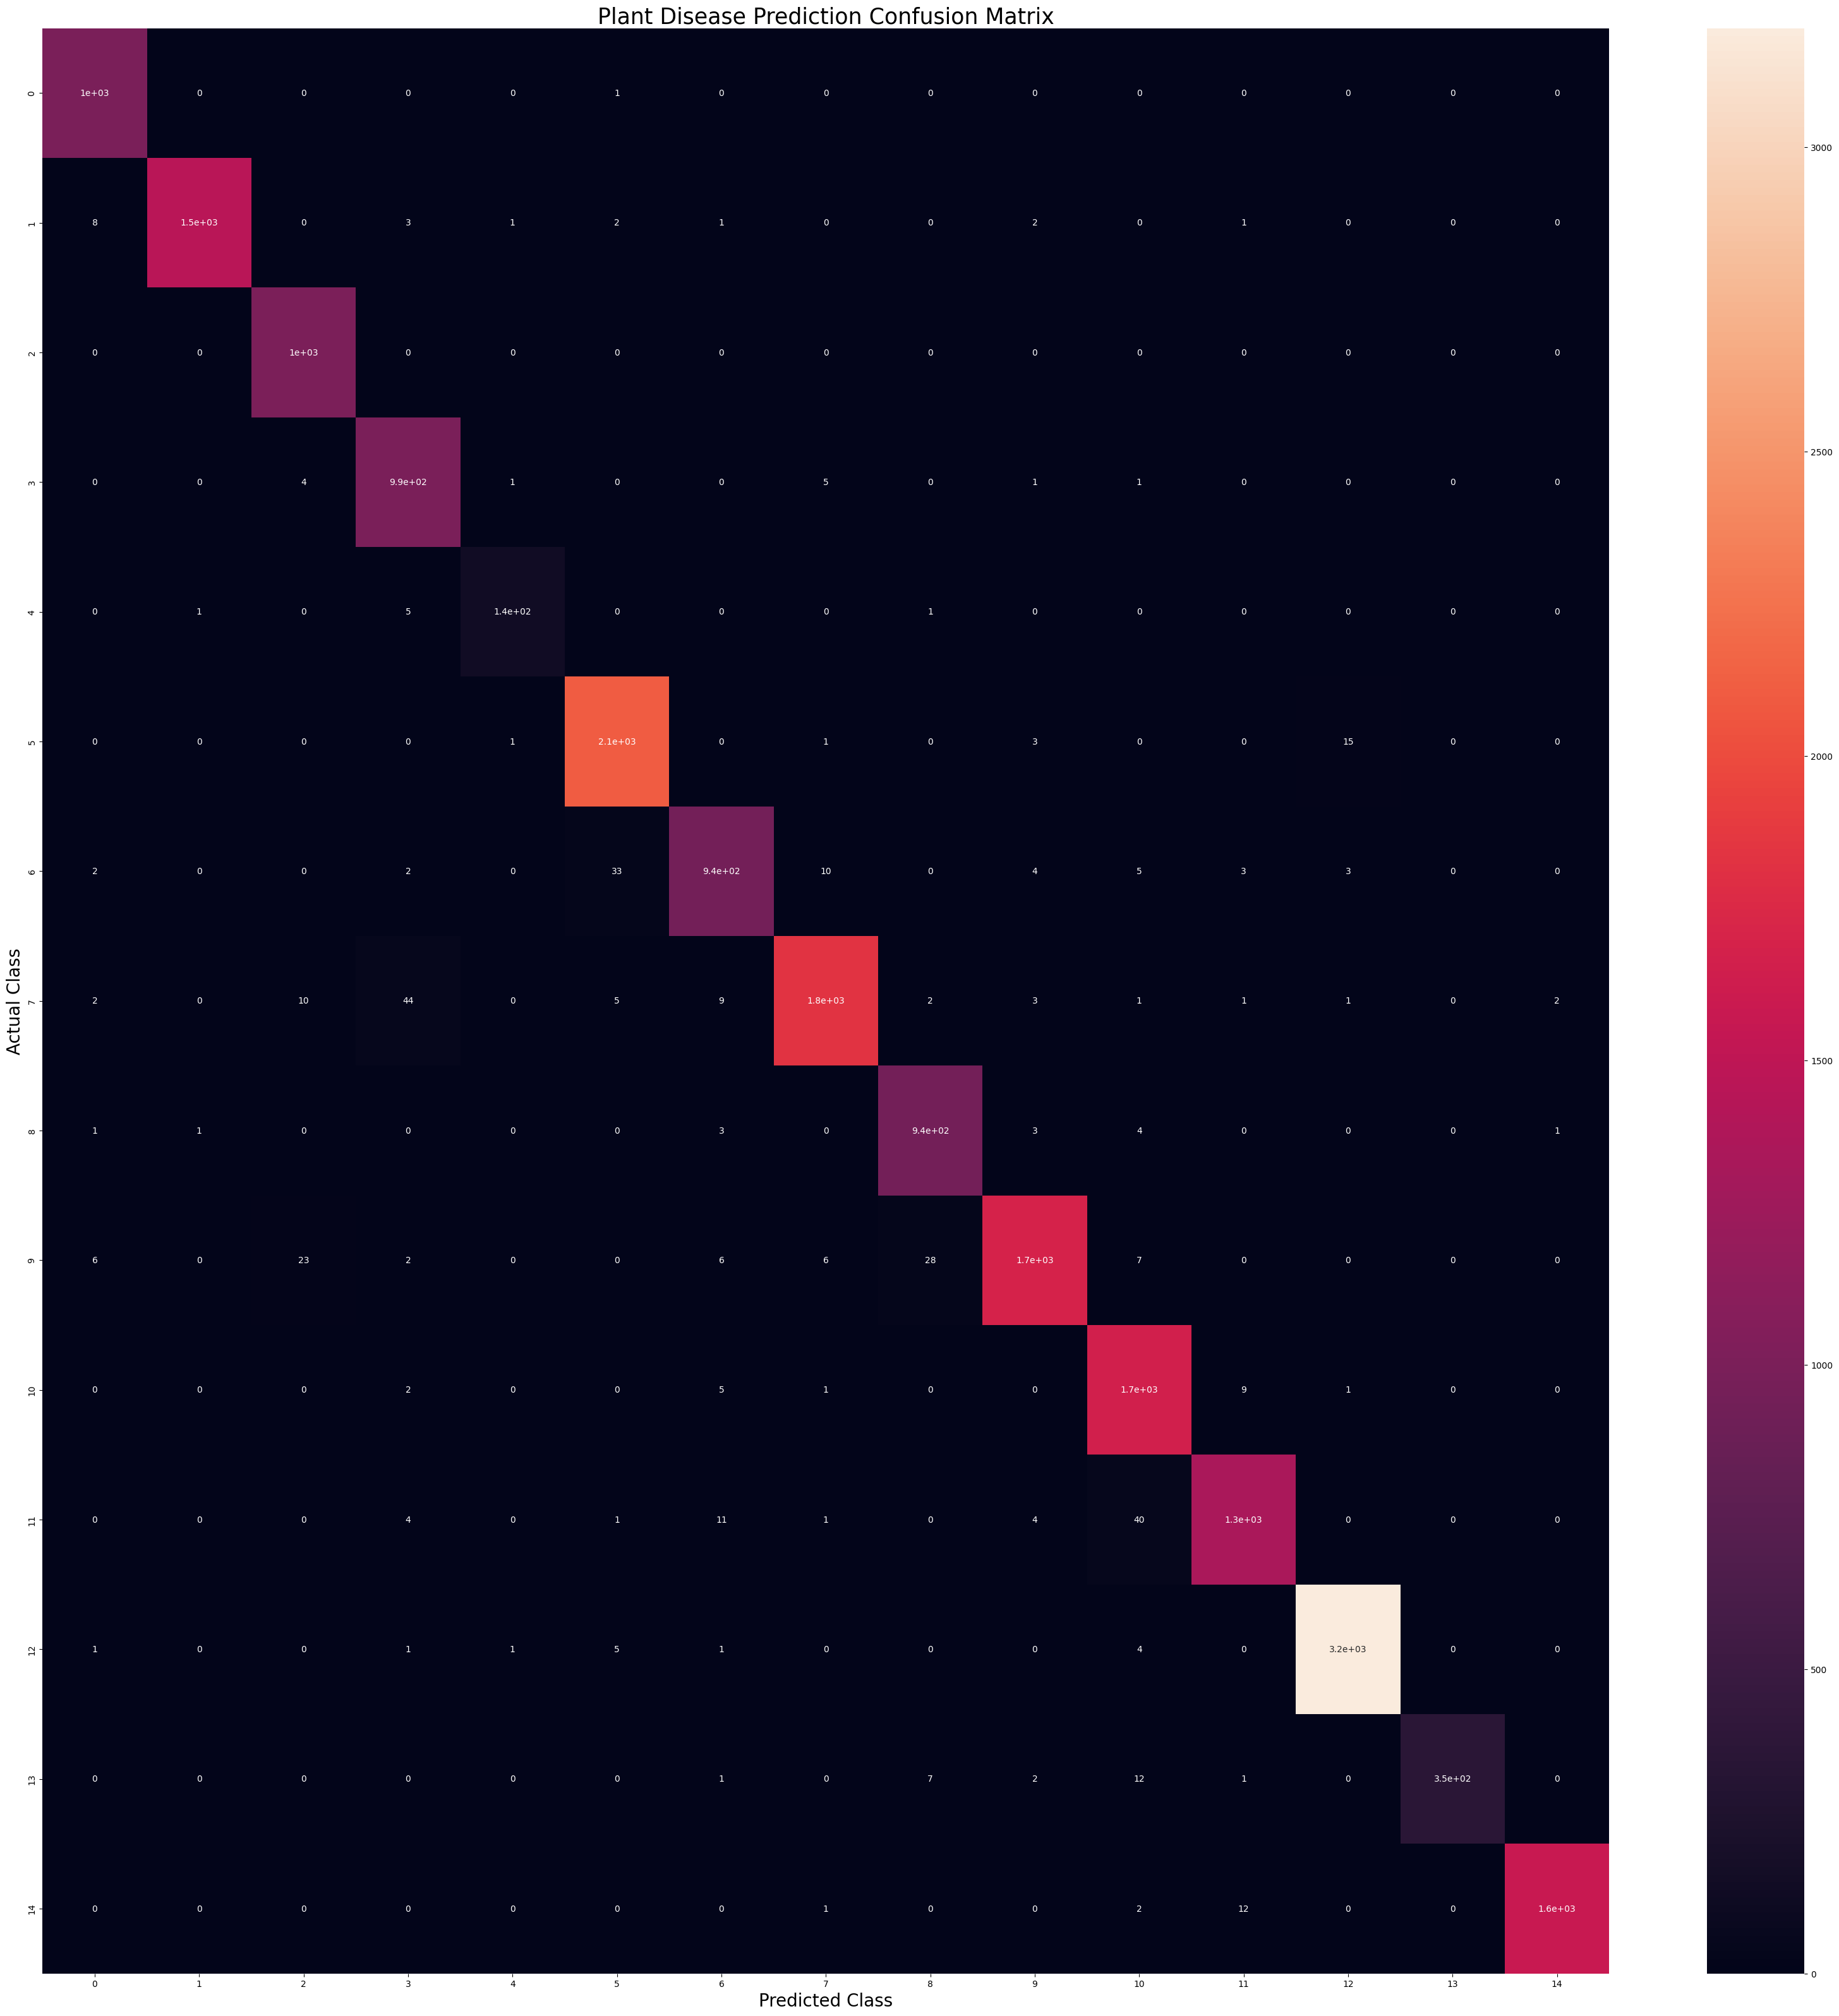

In [50]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()